# Projeto Avaliativo — Módulo 1
## Análise de Risco de Crédito — EDA, Data Prep, Feature Engineering e Machine Learning

**Base que eu escolhi:** Base A (Crédito) — `credit_risk_dataset.csv`

**Objetivo:** prever `loan_status` (1 = default / inadimplência, 0 = pagamento em dia),
comparando um modelo **KNN** e uma **Árvore de Decisão**, com diagnóstico de overfitting
e veredito final orientado ao impacto financeiro do erro. Que será colocado no final.


In [389]:
# para manipulação dos dados
import pandas as pd
# processamento matemático e matrizes numéricas puras
import numpy as np
# bibliotecas de plotagem
import matplotlib.pyplot as plt
import seaborn as sns
# treino e teste biblioteca
from sklearn.model_selection import train_test_split
#  Pré processamento
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
# Modelo KNN
from sklearn.neighbors import KNeighborsClassifier
# Arvore de decisão
from sklearn.tree import DecisionTreeClassifier
# Métricas que irão medir o modelo 
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              f1_score, recall_score)

# Método under-sampling da biblioteca imblearn
from imblearn.under_sampling import RandomUnderSampler


---
## Fase 1: Análise Exploratória de Dados (EDA)

In [390]:
# Importando os dados com pd.read_csv direto na fonte
df = pd.read_csv("/home/delmar/Downloads/credit_risk_dataset(1).csv")

# forma ou dimensão das linhas e colunas
print(f"Formato da base: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head() # imprimi as 5 primeiras 


Formato da base: 32581 linhas x 12 colunas


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [391]:
# Informativo detalhado dos dados
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [392]:
# método adicional:
'''é um atributo utilizado para transpor matrizes ou tabelas, ou seja, ele inverte 
os eixos do seu conjunto de dados. Ele transforma linhas em colunas e colunas em linhas''' 

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


#### Distribuições de variáveis numéricas-chave
(idade, renda e valor do empréstimo).

/tmp/ipykernel_9713/3150678093.py:9: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sns.histplot(df["person_income"].clip(upper=df["person_income"].quantile(0.99)),


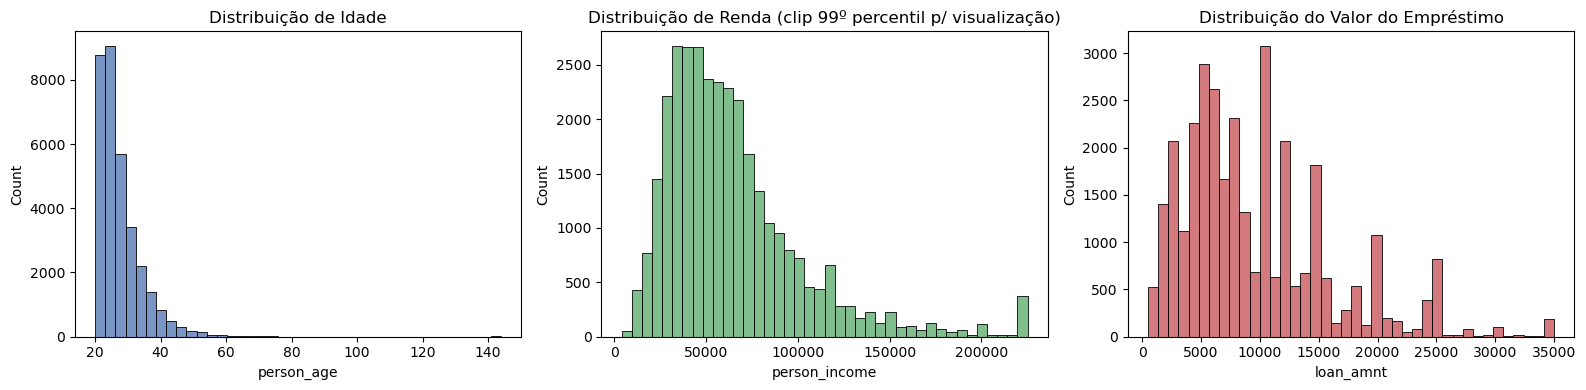

In [393]:
# tamanho da figuras e eixos do grafico
fig, axes = plt.subplots(1, 3, figsize=(16, 4)) 

# Grafico 1
sns.histplot(df["person_age"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuição de Idade")

# Grafic 2
sns.histplot(df["person_income"].clip(upper=df["person_income"].quantile(0.99)),
             bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Distribuição de Renda (clip 99º percentil p/ visualização)")

# Grafico 3
sns.histplot(df["loan_amnt"], bins=40, ax=axes[2], color="#C44E52")
axes[2].set_title("Distribuição do Valor do Empréstimo")
plt.tight_layout()
plt.show()


#### Desbalanceamento da variável-alvo `loan_status`

Agora vamos plotar a diferença entre os clientes de status 0 e 1 

/tmp/ipykernel_9713/4049443689.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="loan_status", data=df, palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_9713/4049443689.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0 - Adimplente", "1 - Default"])


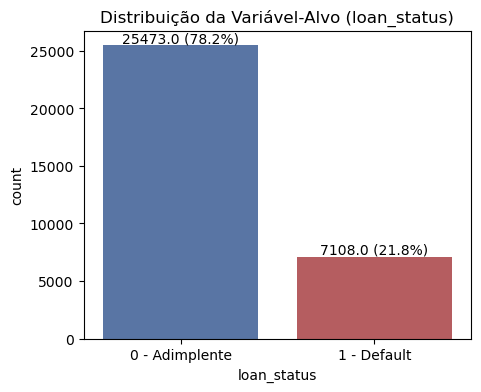

loan_status
0    0.781836
1    0.218164
Name: proporção, dtype: float64


In [394]:
# tamanho da figuras e eixos do grafico
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="loan_status", data=df, palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["0 - Adimplente", "1 - Default"])
for p in ax.patches:
    pct = 100 * p.get_height() / len(df)
    ax.annotate(f"{p.get_height()} ({pct:.1f}%)", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.title("Distribuição da Variável-Alvo (loan_status)")
plt.show()


# Representação de porcentagem dos dados de cada (0 e 1)
print(df["loan_status"].value_counts(normalize=True).rename("proporção"))


#### Mapa de calor de correlação de Pearson (variáveis numéricas)

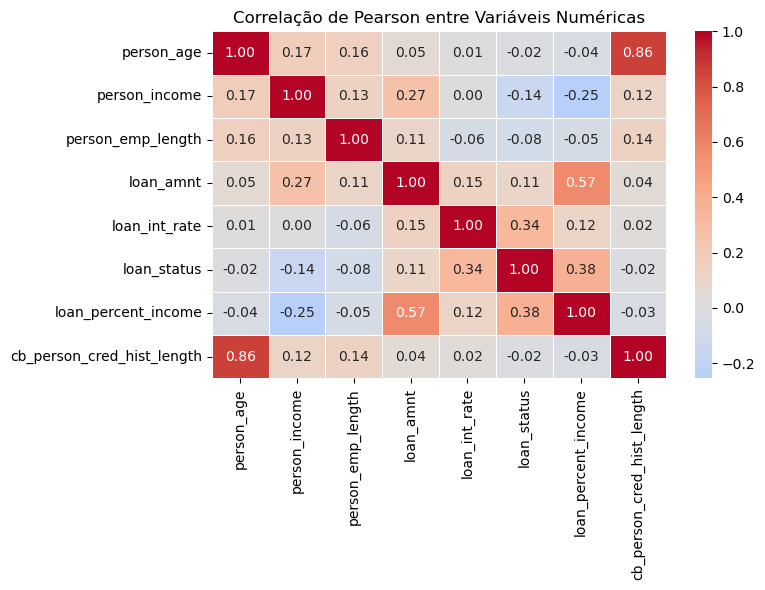

In [395]:
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(method="pearson"), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5)
plt.title("Correlação de Pearson entre Variáveis Numéricas")
plt.tight_layout()
plt.show()


### Tomada de Decisão (Fase 1)

- **A base tem 32.581 linhas e 12 colunas**, com dois campos numéricos incompletos:
  `person_emp_length` (2,7% de nulos) e `loan_int_rate` (9,6% de nulos). Isso exige uma
  estratégia de imputação bem justificada na Fase 2, e não uma simples remoção de linhas
  (que descartaria quase 10% da base).
- O histograma de `person_age` mostra concentração entre 20 e 30 anos, mas com uma cauda
  longa até valores fisicamente implausíveis (>100 anos) — sinal claro de outliers a
  tratar na Fase 2, o que também aparecerá nos boxplots.
- **A variável-alvo é desbalanceada (78% classe 0 vs 22% classe 1)**. Se os modelos forem
  treinados sem correção, tenderão a "chutar" sempre a classe majoritária e a parecer bons
  na acurácia, mas ruins em detectar o default (a classe que realmente importa para o
  negócio). Isso confirma a necessidade de balanceamento **apenas no treino** na Fase 4.
- O mapa de correlação mostra que `loan_amnt` e `loan_percent_income` têm relação
  moderada/forte com o valor emprestado, e `cb_person_cred_hist_length` está fortemente
  correlacionado com `person_age` (faz sentido: quanto mais velho, mais tempo de histórico
  de crédito). Essa colinearidade é mais um argumento para preferir modelos baseados em
  árvore (que lidam bem com variáveis redundantes) e para ter cuidado ao interpretar
  coeficientes/distâncias no KNN.


---
## Fase 2: Tratamento e Limpeza (Dados Preparatorio)

###  Duplicadas

In [396]:
# Vendo quantas duplicadas tem e printando
dup = df.duplicated().sum()
print(f"Linhas duplicadas encontradas: {dup}")

# Eliminando essas duplicadas e vendo o novo formato do dataset
df = df.drop_duplicates().reset_index(drop=True) # #  reset_index para criar uma nova sequência numérica para as linhas, jogando o índice antigo como uma nova coluna. 
print(f"Novo formato após remoção: {df.shape}")


Linhas duplicadas encontradas: 165
Novo formato após remoção: (32416, 12)


### Valores Nulos

- `person_emp_length` (tempo de emprego): a distribuição é **fortemente assimétrica à
  direita** (assimetria ≈ 2,6, com mediana = 4 e valores extremos acima de 100). Nesse
  cenário a **média seria puxada pelos outliers** e não representaria bem um funcionário
  "típico" — por isso a imputação correta aqui é pela **Mediana**.
- `loan_int_rate` (taxa de juros): a distribuição é próxima da simétrica (assimetria ≈
  0,21, bem perto de 0), então a **Média** é uma estimativa estável e não é distorcida por
  outliers relevantes — por isso a imputação aqui é pela **Média**.


In [397]:
# Dados antes do tratamentodos nulos
print("Nulos antes do tratamento:")

# imprimir as duas colunas e seus valores totais nulos presentes 
print(df[["person_emp_length", "loan_int_rate"]].isnull().sum())


'''skew() (geralmente usada nas bibliotecas Pandas ou SciPy) calcula a assimetria (ou distorção) de um conjunto de dados. 
Ela mede o grau de desvio de uma distribuição em relação à sua simetria perfeita'''
# print(f"\nAssimetria person_emp_length: {df['person_emp_length'].skew():.2f}")
# print(f"Assimetria loan_int_rate: {df['loan_int_rate'].skew():.2f}")

print("\n")


# Desvio padrao dos dados
print(np.std(df['person_emp_length']))
print(np.std(df['loan_int_rate']))


# A mediana e media do dados atuais
mediana_emp_length = df["person_emp_length"].median()
media_int_rate = df["loan_int_rate"].mean()

# Agora vamos substituir os valores das respectivas tabelas por suas media e mediana
df["person_emp_length"] = df["person_emp_length"].fillna(mediana_emp_length)
df["loan_int_rate"] = df["loan_int_rate"].fillna(media_int_rate)


# Imprimindo os valores feitos
print(f"A mediana: ", mediana_emp_length, "\nE a média: ", media_int_rate)

# Agora se imprimir os valores nulos  depois de os dados estarem tratados nas 2 colunas
print("\nNulos depois do tratamento:")
print(df[["person_emp_length", "loan_int_rate"]].isnull().sum())


Nulos antes do tratamento:
person_emp_length     887
loan_int_rate        3095
dtype: int64


4.145423826404987
3.2416251337886894
A mediana:  4.0 
E a média:  11.017265100098905

Nulos depois do tratamento:
person_emp_length    0
loan_int_rate        0
dtype: int64


### Tratamento de Outliers

Boxplots para inspecionar `person_age` e `person_emp_length`, as duas variáveis com
valores fisicamente implausíveis identificados na Fase 1 (idade de 144 anos e tempo de
emprego de 123 anos).

O motivo dese grafico é que se um cliente de idade acima de 100 anos signoifica erro 

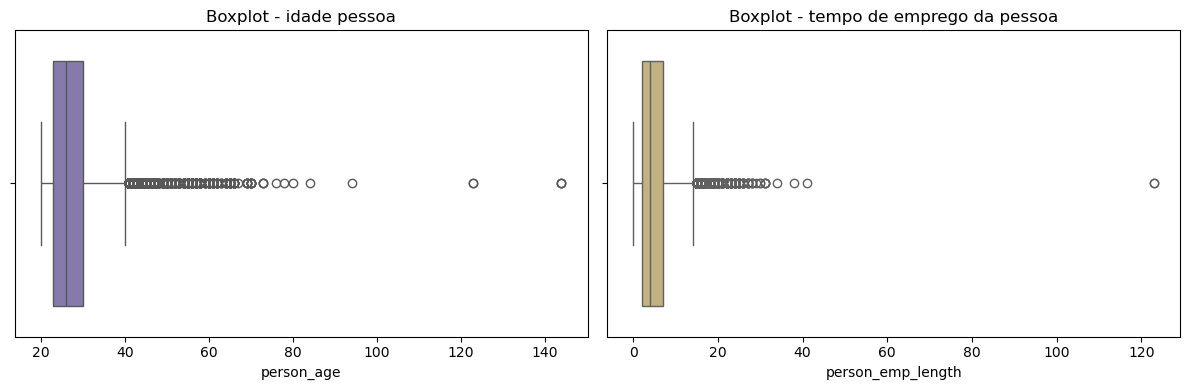

Idades acima de 100 anos: 5
Tempo de emprego acima de 60 anos: 2


In [398]:
# tamanho da figuras e eixos do grafico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["person_age"], ax=axes[0], color="#8172B2")
axes[0].set_title("Boxplot - idade pessoa")
sns.boxplot(x=df["person_emp_length"], ax=axes[1], color="#CCB974")
axes[1].set_title("Boxplot - tempo de emprego da pessoa")
plt.tight_layout()
plt.show()

print("Idades acima de 100 anos:", (df["person_age"] > 100).sum())
print("Tempo de emprego acima de 60 anos:", (df["person_emp_length"] > 60).sum())


**Decisão fundamentada: Remoção.**

Optei por **remover** (e não fazer *clipping*) os registros com `person_age > 100` e
`person_emp_length > 60`. A razão é que esses não são "valores extremos porém válidos"
(como um empréstimo muito alto) — são **erros de entrada fisicamente impossíveis** (ex.:
144 anos de idade, 123 anos trabalhando). Fazer *clipping* nesses casos criaria um valor
artificial (ex.: "empurrar" 144 para 100) que não corresponde a nenhuma pessoa real na
base, então a remoção é mais honesta com os dados. Como afetam poucas linhas (menos de
0,1% da base), a remoção não compromete o tamanho da amostra.

*Nota da minha aplicação professor:* esse tratamento é especialmente importante para o **KNN**,
que mede distância euclidiana entre pontos — um outlier de 144 anos distorceria
fortemente as distâncias calculadas. Já a **Árvore de Decisão** é naturalmente robusta a
outliers, pois faz cortes por limiar (`> ou <=`) e não usa distância — um valor de 144
apenas cairia no mesmo ramo que valores "altos" de idade.

In [399]:
# vamos dividir o formato anterior com agora
antes = df.shape[0]

# Vamos pegar das respectivas colunas abaixo com limitação
# 'Idade' e 'tempo de emprego da pessoa'
# reset_index para criar uma nova sequência numérica para as linhas, jogando o índice antigo como uma nova coluna. 
df = df[(df["person_age"] <= 100) & (df["person_emp_length"] <= 60)].reset_index(drop=True)
depois = df.shape[0]
print(f"Linhas removidas por outlier: {antes- depois}")

# print na tela o novo formato do data
print(f"Formato final após limpeza: {df.shape}")


Linhas removidas por outlier: 7
Formato final após limpeza: (32409, 12)


---
## Fase 3: Feature Engineering (Coluna Calculada)

Criação da coluna `comprometimento_renda`, que representa o percentual da renda anual
comprometido com o valor do empréstimo solicitado. Os nulos das colunas originais já
foram tratados na Fase 2, então não há risco de contaminação por `NaN`/infinitos aqui.

In [400]:
#a nova coluna que será inserida
df["comprometimento_renda"] = (df["loan_amnt"] / df["person_income"]) * 100

# descrição dessa nova coluna
print(df["comprometimento_renda"].describe())

# Abaixo agora vamos ver e ter certeza que não foi gerado algum valor nulo ou inválido
# .isinf() serve para verificar se um determinado valor numérico é infinito. Ele retorna True(1) se o valor for infinito positivo ou negativo, e False(0) caso contrário.
print("\nInfinitos ou nulos gerados:",
      np.isinf(df["comprometimento_renda"]).sum() + df["comprometimento_renda"].isnull().sum())


count    32409.000000
mean        17.059651
std         10.705381
min          0.078947
25%          8.972231
50%         14.814815
75%         22.916667
max         83.000000
Name: comprometimento_renda, dtype: float64

Infinitos ou nulos gerados: 0


---
## Fase 4: Separação, Balanceamento e Escalonamento Seguro

### Encoding
- **One-Hot Encoding** para variáveis nominais sem ordem natural:
  `person_home_ownership`, `loan_intent`, `cb_person_default_on_file`.
- **Label/Ordinal Encoding** para `loan_grade`, pois as notas de crédito A→G têm uma
  **ordem natural de risco crescente** (A = melhor risco, G = pior risco), o que o
  One-Hot ignoraria.

In [401]:
# DICIONARIO QUE SERÁ UTILIZADO PARA ENCODING DA COLUNA LOAN_GRADE
dic_order = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}

# só aplica o mapeamento se a coluna ainda estiver como texto (evita virar NaN se já rodou antes)
if df['loan_grade'].dtype == object:
    df['loan_grade'] = df['loan_grade'].map(dic_order)

# só faz o One-Hot nas colunas que ainda existirem no df
col_para_encoding = ['cb_person_default_on_file', 'person_home_ownership', 'loan_intent']

# Lista de Compreensão que percorre cada nome de coluna dentro da sua lista de interesse.
# if c in df.columns: Verifica se o nome da coluna existe no DataFrame ativo.
col_presentes = [c for c in col_para_encoding if c in df.columns]

# get_dummies() converte variáveis categóricas em representações numéricas
df = pd.get_dummies(df, columns=col_presentes, drop_first=True) # drop_first=true, joga o primeiro fora

display(df)

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda,cb_person_default_on_file_Y,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,21,9600,5.0,2,1000,11.14,0,0.10,2,10.416667,False,False,True,False,True,False,False,False,False
1,25,9600,1.0,3,5500,12.87,1,0.57,3,57.291667,False,False,False,False,False,False,True,False,False
2,23,65500,4.0,3,35000,15.23,1,0.53,2,53.435115,False,False,False,True,False,False,True,False,False
3,24,54400,8.0,3,35000,14.27,1,0.55,4,64.338235,True,False,False,True,False,False,True,False,False
4,21,9900,2.0,1,2500,7.14,1,0.25,2,25.252525,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32404,57,53000,1.0,3,5800,13.16,0,0.11,30,10.943396,False,False,False,False,False,False,False,True,False
32405,54,120000,4.0,1,17625,7.49,0,0.15,19,14.687500,False,False,False,False,False,False,False,True,False
32406,65,76000,3.0,2,35000,10.99,1,0.46,28,46.052632,False,False,False,True,False,True,False,False,False
32407,56,150000,5.0,2,15000,11.48,0,0.10,26,10.000000,False,False,False,False,False,False,False,True,False


### 4.2 Split de Dados (Treino/Teste)

In [402]:
# Definindo os valores X e y
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

# Definindo os dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


# Imprimindo na tela tamanho dos X em treino e teste
print("Treino:", X_train.shape, "  Teste:", X_test.shape)

# Y.treino em frequência de valores únicos em uma coluna (Series)  0 e 1
print("\nProporção da classe no treino:")
print(y_train.value_counts(normalize=True))

# O mesmo que dos treino mas aplicado ao teste de y
print("\nProporção da classe no teste:")
print(y_test.value_counts(normalize=True))


Treino: (25927, 18)   Teste: (6482, 18)

Proporção da classe no treino:
loan_status
0    0.781309
1    0.218691
Name: proportion, dtype: float64

Proporção da classe no teste:
loan_status
0    0.78124
1    0.21876
Name: proportion, dtype: float64


### 4.3 Balanceamento de Classes

**Regra de Ouro:** o balanceamento é aplicado **estritamente nos dados de treino**, nunca
no teste — o conjunto de teste deve continuar representando a distribuição real do mundo
(desbalanceada) para que a avaliação final seja honesta e livre de vazamento de dados
(*Data Leakage*).

Técnica escolhida: **Random Under Sampling** da classe majoritária. Como a base tem mais
de 32 mil linhas mesmo após a limpeza, reduzir a classe majoritária não compromete o
volume de dados de treino disponível, e evita o risco de gerar exemplos sintéticos
pouco realistas em variáveis financeiras sensíveis (o que poderia acontecer com SMOTE).

In [403]:
# Tecnica de Under-Sampling
rus = RandomUnderSampler(random_state=42)

# Aplicando ela ao dados de treino de X e Y
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)


# Imprimindo frequência de valores únicos em uma coluna (Series) em dicionario
print("Antes do balanceamento:", y_train.value_counts().to_dict())
print("Depois do balanceamento:", y_train_bal.value_counts().to_dict())


Antes do balanceamento: {0: 20257, 1: 5670}
Depois do balanceamento: {0: 5670, 1: 5670}


### Escalonamento Seguro (apenas para o KNN)

O `StandardScaler` é ajustado (`fit_transform`) **exclusivamente com os dados de treino
já balanceados**, e aplicado (`transform`) no teste — nunca o inverso, para não vazar
informação estatística do teste para o treino.

Esse escalonamento é usado **apenas no KNN**, que depende de distância euclidiana entre
os pontos (variáveis em escalas diferentes, como renda em milhares e idade em unidades,
dominariam a distância se não fossem padronizadas).

A **Árvore de Decisão é treinada com os dados originais, sem escalonamento**: o algoritmo
de árvore faz cortes univariados por limiar (ex.: `person_income <= 45000`), que são
**monotônicos** — ou seja, qualquer transformação que preserve a ordem dos valores (como
o StandardScaler) não muda em nada as decisões da árvore, apenas mudaria a escala do
limiar exibido. Escalonar seria trabalho computacional desnecessário.

In [404]:
# Escalonando os dados
scaler = StandardScaler()

# Abaixo vamos fazero escalonamento aplicado a dados de treino e test do Xe imprimir
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# imprimindo os dados escalonados em seus novos formatos
print("Dados escalonados (para o KNN) prontos:", X_train_scaled.shape, X_test_scaled.shape)
print("Dados NÃO escalonados (para a Árvore) prontos:", X_train_bal.shape, X_test.shape)


Dados escalonados (para o KNN) prontos: (11340, 18) (6482, 18)
Dados NÃO escalonados (para a Árvore) prontos: (11340, 18) (6482, 18)


---
## Fase 5: Modelagem e Validação (O Desafio do Overfitting)

### Otimização do KNN — variando `n_neighbors`

In [405]:
# modelo knn
knn_results = []  # lista vazia onde vamos guardar o resultado de cada teste com um valor de k diferente

# Vamos aplicar o numero de variações nesse modelo com ajuda do loop
for k in [3, 5, 7, 9]:  # repete o processo abaixo 4 vezes, uma para cada valor de k (quantidade de "vizinhos" que o KNN vai olhar)
    knn = KNeighborsClassifier(n_neighbors=k)  # k é definido no loop
    knn.fit(X_train_scaled, y_train_bal)  # dados escalonados com repasse do modelo em suas variações aplicada

    acc_train = accuracy_score(y_train_bal, knn.predict(X_train_scaled))  # calcula o quanto o modelo acertou nos próprios dados de treino
    acc_test = accuracy_score(y_test, knn.predict(X_test_scaled))  # calcula o quanto o modelo acertou em dados novos (teste), que ele nunca viu
    f1_test = f1_score(y_test, knn.predict(X_test_scaled))  # calcula uma nota que equilibra acerto e erro nos casos de inadimplência (mais justa que só a acurácia)

    knn_results.append({"k": k, "acc_treino": acc_train, "acc_teste": acc_test, "f1_teste": f1_test})  # guarda os resultados desse k na lista, para comparar depois

knn_results_df = pd.DataFrame(knn_results)  # transforma a lista de resultados numa tabela, mais fácil de ler
knn_results_df  # mostra essa tabela na tela


,k,acc_treino,acc_teste,f1_teste
0,3,0.891799,0.808855,0.635052
1,5,0.862610,0.820117,0.646667
2,7,0.852734,0.829682,0.660934
3,9,0.845767,0.836933,0.671841


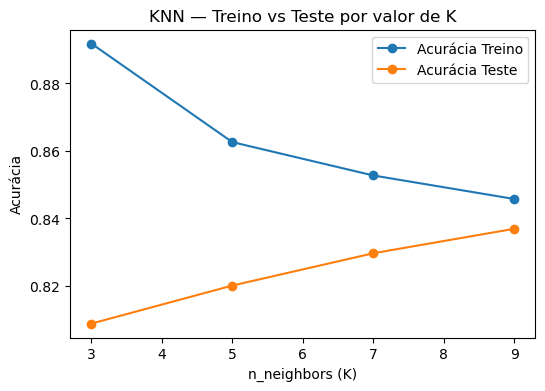

In [406]:
plt.figure(figsize=(6, 4))  # cria uma figura (área de desenho) do gráfico, com 6 de largura por 4 de altura
plt.plot(knn_results_df["k"], knn_results_df["acc_treino"], marker="o", label="Acurácia Treino")  # desenha a linha da acurácia no TREINO, para cada valor de K, com uma bolinha em cada ponto
plt.plot(knn_results_df["k"], knn_results_df["acc_teste"], marker="o", label="Acurácia Teste")  # desenha a linha da acurácia no TESTE, para cada valor de K, com uma bolinha em cada ponto
plt.xlabel("n_neighbors (K)")  # escreve o nome do eixo X (o valor de K usado no KNN)
plt.ylabel("Acurácia")  # escreve o nome do eixo Y (a taxa de acerto do modelo)
plt.title("KNN — Treino vs Teste por valor de K")  # escreve o título do gráfico
plt.legend()  # mostra a legenda (qual linha é treino e qual é teste)
plt.show()  # exibe o gráfico na tela


### 5.2 Otimização da Árvore de Decisão — variando `max_depth`

In [407]:
# lista com os valores de profundidade máxima que vamos testar na árvore
# (None significa "sem limite", a árvore pode crescer o quanto quiser)
tree_depths = [3, 5, 7, None]

# lista vazia onde vamos guardar o resultado (acurácia etc.) de cada teste
tree_results = []

# repete o processo de treinar e avaliar uma árvore para cada profundidade da lista acima
for depth in tree_depths:
    # cria uma árvore de decisão nova, com a profundidade máxima da vez
    # random_state=42 é só para o resultado ser sempre o mesmo toda vez que rodar
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # treina a árvore (ela "aprende" olhando os dados de treino já balanceados)
    tree.fit(X_train_bal, y_train_bal)

    # pede pra árvore prever os próprios dados de treino, e compara com a resposta certa
    # isso mostra o quanto o modelo "decorou" o treino
    acc_train = accuracy_score(y_train_bal, tree.predict(X_train_bal))

    # pede pra árvore prever os dados de teste (que ela nunca viu) e compara com a resposta certa
    # isso mostra se o modelo realmente aprendeu ou só decorou
    acc_test = accuracy_score(y_test, tree.predict(X_test))

    # calcula o F1-score no teste, uma métrica que junta precisão e recall em um só número
    f1_test = f1_score(y_test, tree.predict(X_test))

    # guarda os resultados dessa profundidade numa lista, num formato de "tabela"
    # se a profundidade for None, escreve "Ilimitada" pra ficar mais fácil de ler
    tree_results.append({
        "max_depth": "Ilimitada" if depth is None else depth,
        "acc_treino": acc_train, "acc_teste": acc_test, "f1_teste": f1_test
    })

# transforma a lista de resultados numa tabela (DataFrame) do pandas, mais fácil de visualizar
tree_results_df = pd.DataFrame(tree_results)

# mostra a tabela final, com uma linha para cada profundidade testada
tree_results_df


,max_depth,acc_treino,acc_teste,f1_teste
0,3,0.830511,0.881518,0.735172
1,5,0.843915,0.892317,0.758645
2,7,0.852116,0.910367,0.786161
3,Ilimitada,1.000000,0.815798,0.668333


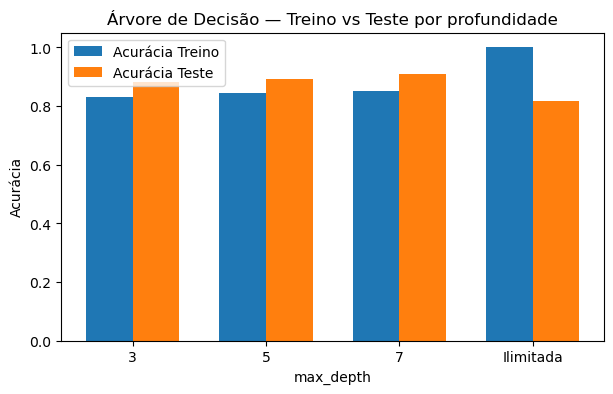

In [408]:
labels = tree_results_df["max_depth"].astype(str)  # pega os valores de max_depth e transforma em texto, pra usar como rótulo no eixo X

x_pos = np.arange(len(labels))  # cria uma posição numérica (0, 1, 2...) pra cada barra no gráfico

width = 0.35  # largura de cada barra

plt.figure(figsize=(7, 4))  # abre a figura do gráfico com esse tamanho

plt.bar(x_pos - width/2, tree_results_df["acc_treino"], width, label="Acurácia Treino")  # barra da acurácia de treino, um pouco à esquerda
plt.bar(x_pos + width/2, tree_results_df["acc_teste"], width, label="Acurácia Teste")  # barra da acurácia de teste, um pouco à direita
plt.xticks(x_pos, labels)  # troca os números do eixo X pelos rótulos de max_depth

plt.xlabel("max_depth")  # nome do eixo X
plt.ylabel("Acurácia")  # nome do eixo Y

plt.title("Árvore de Decisão — Treino vs Teste por profundidade")  # título do gráfico

plt.legend()  # mostra a legenda (treino/teste)
plt.show()  # exibe o gráfico na tela


### 5.3 Diagnóstico de Overfitting

- **KNN:** a acurácia de treino e teste ficam relativamente próximas em todos os valores
  de K testados (o KNN "memoriza" menos, pois decide na hora da previsão). Ainda assim,
  K muito baixo (K=3) tende a ser mais sensível a ruído local (fronteiras mais irregulares),
  enquanto K muito alto tende a suavizar demais a fronteira de decisão. Um K intermediário
  (5 ou 7) tende a equilibrar melhor viés e variância.
- **Árvore de Decisão:** este é o caso clássico de overfitting pedido pelo desafio. Com
  `max_depth=None` (ilimitada), a árvore **decora o treino** — a acurácia de treino chega
  perto de 100%, mas a acurácia de teste é visivelmente menor, evidenciando que o modelo
  aprendeu ruído específico dos dados de treino em vez de um padrão generalizável.
  Profundidades controladas (`max_depth=5` ou `7`) mantêm a acurácia de treino mais
  próxima da de teste, o que indica **melhor capacidade de generalização** — essa é a
  configuração que deve ser preferida sobre a árvore ilimitada, mesmo que a árvore
  ilimitada pareça "melhor" olhando só para o treino.


---
## Fase 6: Avaliação e Veredito de Negócios

Selecionando as duas melhores configurações da fase anterior (a melhor profundidade de
árvore encontrada e o melhor K do KNN) para uma comparação final detalhada.

In [409]:
best_k = 7 # valor de K (vizinhos) escolhido como o melhor para o KNN
best_depth = 5  # profundidade máxima escolhida como a melhor para a Árvore

final_knn = KNeighborsClassifier(n_neighbors=best_k)   # cria o modelo KNN com esse K
final_knn.fit(X_train_scaled, y_train_bal)             # treina o KNN com os dados escalonados e balanceados
pred_knn = final_knn.predict(X_test_scaled)   # gera as previsões do KNN em cima do teste

final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)  # cria o modelo de Árvore com essa profundidade
final_tree.fit(X_train_bal, y_train_bal)     # treina a Árvore com os dados balanceados (sem escalonar)
pred_tree = final_tree.predict(X_test)        # gera as previsões da Árvore em cima do teste

print("="*60)                  # linha decorativa só para separar visualmente o bloco do KNN


print(f"KNN (k={best_k}) — Classification Report")   # título mostrando qual modelo é esse relatório


print("="*60)                  # fecha a linha decorativa


print(classification_report(y_test, pred_knn, target_names=["Adimplente (0)", "Default (1)"]))
# compara o real (y_test) com o previsto (pred_knn) e imprime precisão, recall e f1 de cada classe



print("="*60)                  # linha decorativa separando o bloco da Árvore


print(f"Árvore de Decisão (max_depth={best_depth}) — Classification Report")  # título do relatório da Árvore
print("="*60)                  # fecha a linha decorativa


print(classification_report(y_test, pred_tree, target_names=["Adimplente (0)", "Default (1)"]))
# mesma comparação de antes, agora usando as previsões da Árvore (pred_tree)


KNN (k=7) — Classification Report
                precision    recall  f1-score   support

Adimplente (0)       0.93      0.85      0.89      5064
   Default (1)       0.59      0.76      0.66      1418

      accuracy                           0.83      6482
     macro avg       0.76      0.80      0.77      6482
  weighted avg       0.85      0.83      0.84      6482

Árvore de Decisão (max_depth=5) — Classification Report
                precision    recall  f1-score   support

Adimplente (0)       0.94      0.93      0.93      5064
   Default (1)       0.74      0.77      0.76      1418

      accuracy                           0.89      6482
     macro avg       0.84      0.85      0.84      6482
  weighted avg       0.89      0.89      0.89      6482



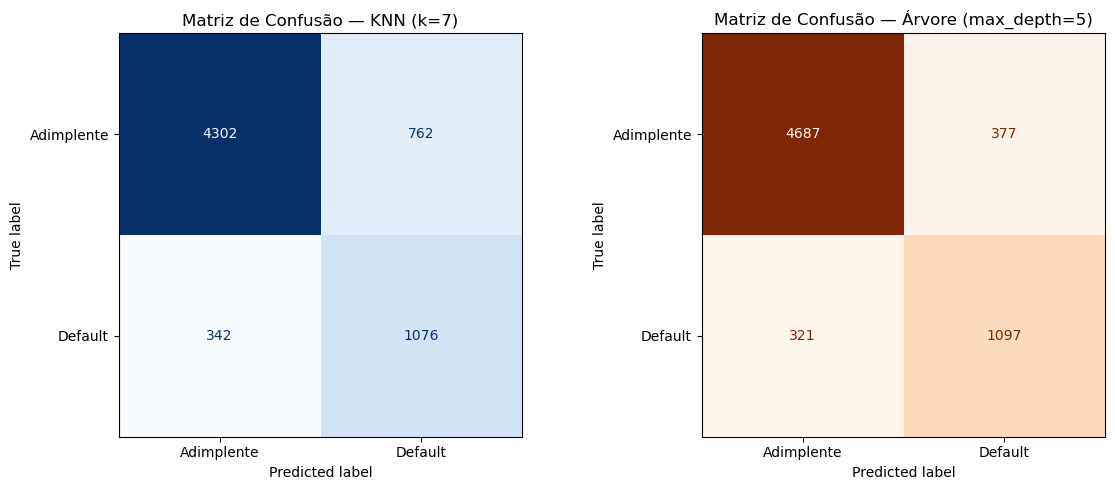

In [410]:
# cria uma figura com 2 gráficos lado a lado (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# calcula a matriz de confusão do KNN (compara o valor real com o que o modelo previu)
cm_knn = confusion_matrix(y_test, pred_knn)


# desenha essa matriz no primeiro gráfico (posição 0), com os rótulos das classes
ConfusionMatrixDisplay(cm_knn, display_labels=["Adimplente", "Default"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)



# coloca um título no primeiro gráfico, mostrando o valor de k usado
axes[0].set_title(f"Matriz de Confusão — KNN (k={best_k})")

# calcula a matriz de confusão da Árvore de Decisão
cm_tree = confusion_matrix(y_test, pred_tree)



# desenha essa matriz no segundo gráfico (posição 1)
ConfusionMatrixDisplay(cm_tree, display_labels=["Adimplente", "Default"]).plot(
    ax=axes[1], cmap="Oranges", colorbar=False)



# coloca um título no segundo gráfico, mostrando a profundidade máxima usada
axes[1].set_title(f"Matriz de Confusão — Árvore (max_depth={best_depth})")

# ajusta os espaços entre os gráficos para não ficarem cortados/sobrepostos
plt.tight_layout()


# exibe a figura na tela
plt.show()


### Análise de Negócio e Veredito Final

No contexto de **risco de crédito**, os dois tipos de erro têm custos muito diferentes:

- **Falso Positivo** (o modelo prevê *default*, mas o cliente pagaria em dia): a
  instituição perde uma venda/juros que teria ganho ao negar ou encarecer o crédito de um
  bom pagador. É um custo de **oportunidade**.
- **Falso Negativo** (o modelo prevê *pagamento em dia*, mas o cliente realmente dá
  *default*): a instituição **empresta o dinheiro e não recebe de volta** — é uma perda
  direta do principal emprestado, tipicamente muito maior que o custo de oportunidade de
  um Falso Positivo.

**Portanto, o pior erro financeiro é o Falso Negativo**, e o critério de escolha do
melhor modelo não deve ser apenas a acurácia geral, e sim o **recall da classe 1
(Default)** — a capacidade do modelo de capturar o máximo possível dos clientes que
realmente vão inadimplir, mesmo que isso signifique recusar alguns bons pagadores
(Falsos Positivos) no caminho.

**Resultado desta execução:**

| Modelo | Acurácia | Recall (Default) | Precisão (Default) | F1 (Default) |
|---|---|---|---|---|
| KNN (k=7) | 0,83 | 0,76 | 0,59 | 0,66 |
| Árvore (max_depth=5) | 0,89 | 0,77 | 0,74 | 0,76 |

O recall da classe "Default" é **praticamente empatado** entre os dois modelos (0,76 no
KNN vs 0,77 na Árvore) — ambos capturam uma proporção parecida dos clientes que de fato
vão inadimplir. O que diferencia os modelos é a **precisão**: a Árvore erra muito menos
ao "alarmar" default (0,74 contra apenas 0,59 do KNN). Isso significa que, para o mesmo
nível de proteção contra Falsos Negativos, a Árvore recusa/encarece muito menos bons
pagadores (menos Falsos Positivos), gerando menos custo de oportunidade e uma acurácia
geral maior (0,89 vs 0,83).

**Veredito final: a Árvore de Decisão (`max_depth=5`) é o modelo recomendado para
produção.** Ela iguala o KNN na proteção contra o pior erro financeiro (Falso Negativo /
inadimplência não detectada), mas com muito mais precisão — ou seja, entrega o mesmo
nível de segurança ao caixa da instituição com um impacto bem menor sobre clientes bons,
o que se traduz em mais receita preservada e uma operação de crédito mais eficiente.
